In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
#load data
x_train = np.load("../data/X_train.npy")
x_test = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_test = np.load("../data/y_test.npy")

y_train = np.argmax(y_train, axis=1)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


rf_classifier = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=20, min_samples_split=2, 
                                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, 
                                       min_impurity_decrease=0.0, bootstrap=False, oob_score=False, n_jobs=None, random_state=None, 
                                       verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)


rf_classifier.fit(x_train, y_train)


y_pred = rf_classifier.predict_proba(x_test)


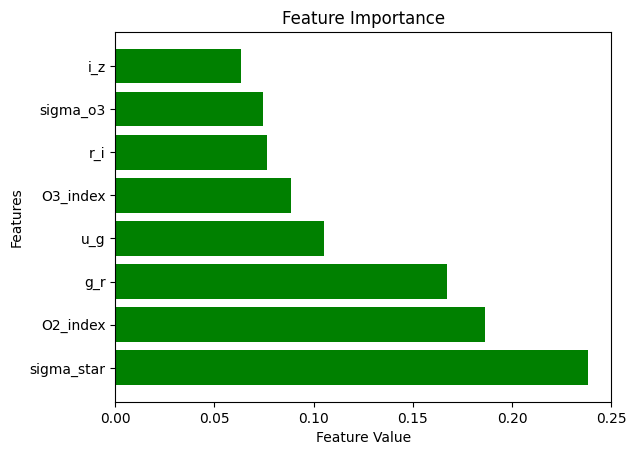

In [3]:
feature = ['O3_index', 'O2_index', 'sigma_star', 'sigma_o3', 'u_g', 'g_r', 'r_i', 'i_z']
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
ordered_feature_names = []
ordered_feature_values = []
for i in indices:
    ordered_feature_names.append(feature[i])
    ordered_feature_values.append(importances[i])

#print(ordered_feature_names)


plt.barh(ordered_feature_names, ordered_feature_values, color='green')

plt.xlabel('Feature Value')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.savefig('../plots/RF_feature_importance.pdf',format='pdf')
plt.show()



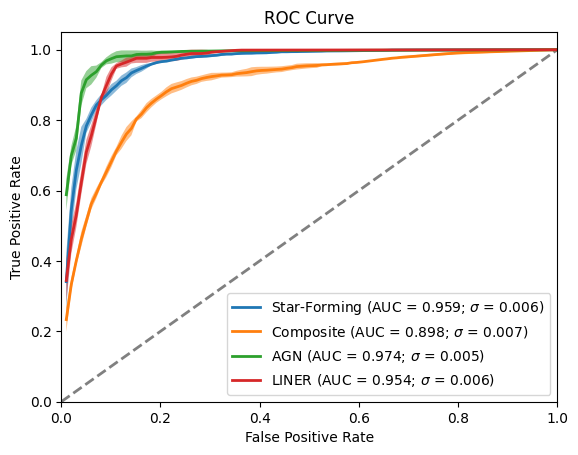

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import numpy as np
from scipy.interpolate import interp1d
import warnings

warnings.filterwarnings("ignore")

y_pred_prob = np.array(y_pred)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure()

classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

n_bootstraps = 5
rng = np.random.RandomState(42)


all_fprs = {i: [] for i in range(4)}
all_tprs = {i: [] for i in range(4)}

mean_fpr_interpolated = np.linspace(0, 1, 100)

for i in range(4):
    for _ in range(n_bootstraps):

        X_resampled, y_resampled = resample(x_test, y_test, random_state=rng)
    
        rf_classifier.fit(x_train, y_train)
        
        y_prob_resampled = rf_classifier.predict_proba(X_resampled)
        
        fpr_resampled, tpr_resampled, _ = roc_curve(y_resampled[:, i], y_prob_resampled[:, i])
        
        f_interp = interp1d(fpr_resampled, tpr_resampled, kind='linear', fill_value="extrapolate")
        tpr_interpolated = f_interp(mean_fpr_interpolated)
        
        all_fprs[i].append(mean_fpr_interpolated)
        all_tprs[i].append(tpr_interpolated)

for i in range(4):
    
    all_fprs[i] = np.array(all_fprs[i])
    all_tprs[i] = np.array(all_tprs[i])
    
    
    mean_tpr = np.mean(all_tprs[i], axis=0)
    mean_fpr = mean_fpr_interpolated  

    
    std_tpr = np.std(all_tprs[i], axis=0)
    nan_to_zero = np.where(np.isnan(std_tpr), 0, std_tpr)
    std_tpr = nan_to_zero

    
    plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,alpha=0.5)
    
    
    plt.plot(mean_fpr, mean_tpr, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}; $\sigma$ = {np.mean(std_tpr):.3f})', lw=2)

plt.legend(loc='lower right')
plt.savefig('../plots/RF_ROC_curve.pdf',format='pdf')
plt.show()

In [8]:
#save random forest model
import joblib
joblib.dump(rf_classifier, '../RandomForest/RF_model.pkl')


['../RandomForest/RF_model.pkl']

In [9]:
file_path_features = '../data/X_extra_data.npy'
X_test = np.load(file_path_features)
file_path_labels = '../data/labels_extra_data.npy'
Y_test = np.load(file_path_labels)
Y_test = np.array(Y_test, dtype=int)

In [11]:
y_pred_new = rf_classifier.predict_proba(X_test)

In [14]:
#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = np.argmax(y_pred_new, axis=1)
y_true = np.argmax(Y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print(accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred, y_true)

0.7142857142857143


array([[104,  21,   5,   1],
       [ 11,   5,   0,   1],
       [  4,   1,   1,   0],
       [  0,   0,   0,   0]])

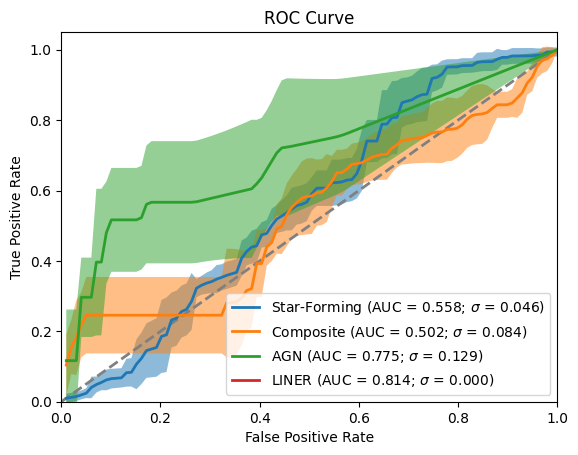

In [13]:
y_pred_prob = np.array(y_pred_new)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure()

classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

n_bootstraps = 5
rng = np.random.RandomState(42)


all_fprs = {i: [] for i in range(4)}
all_tprs = {i: [] for i in range(4)}

mean_fpr_interpolated = np.linspace(0, 1, 100)

for i in range(4):
    for _ in range(n_bootstraps):

        X_resampled, y_resampled = resample(X_test, Y_test, random_state=rng)
    
        #rf_classifier.fit(x_train, y_train)
        
        y_prob_resampled = rf_classifier.predict_proba(X_resampled)
        
        fpr_resampled, tpr_resampled, _ = roc_curve(y_resampled[:, i], y_prob_resampled[:, i])
        
        f_interp = interp1d(fpr_resampled, tpr_resampled, kind='linear', fill_value="extrapolate")
        tpr_interpolated = f_interp(mean_fpr_interpolated)
        
        all_fprs[i].append(mean_fpr_interpolated)
        all_tprs[i].append(tpr_interpolated)

for i in range(4):
    
    all_fprs[i] = np.array(all_fprs[i])
    all_tprs[i] = np.array(all_tprs[i])
    
    
    mean_tpr = np.mean(all_tprs[i], axis=0)
    mean_fpr = mean_fpr_interpolated  

    
    std_tpr = np.std(all_tprs[i], axis=0)
    nan_to_zero = np.where(np.isnan(std_tpr), 0, std_tpr)
    std_tpr = nan_to_zero

    
    plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,alpha=0.5)
    
    
    plt.plot(mean_fpr, mean_tpr, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}; $\sigma$ = {np.mean(std_tpr):.3f})', lw=2)

plt.legend(loc='lower right')
plt.savefig('../plots/RF_ROC_curve.pdf',format='pdf')
plt.show()